# 🎬 Estatística na prática: analisando um catálogo de filmes

Este notebook não tem nenhuma nota nem entrega — é só para você **executar as células e ler os comentários**, na ordem, de cima para baixo. Não precisa escrever nenhum código.

A ideia é simples: tudo que fizemos **à mão** na Aula 1 (classificar variáveis, montar tabela de frequência, desenhar gráficos, calcular moda/mediana/média) o Python faz em segundos — e dá pra fazer isso com qualquer banco de dados do mundo real, não só com o exemplo do livro.

Vamos usar um banco de dados de filmes conhecidos. Bora lá.

## Como executar

Passe o mouse em cima de cada célula de código (as cinzas, com `[ ]` do lado esquerdo) e clique no ▶ que aparece, ou selecione a célula e aperte **Shift+Enter**. Vá executando uma de cada vez, na ordem — algumas células usam o resultado das anteriores.

## 1. Criando o banco de dados

Nada de baixar arquivo de lugar nenhum — os dados já estão escritos direto aqui embaixo, então isso funciona mesmo sem internet boa. É uma tabela com 24 filmes conhecidos e algumas informações de cada um.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# cada linha é um filme; cada coluna é uma variável (do jeito que vimos na Aula 1)
dados = {
    "titulo": ["Vingadores: Ultimato", "Toy Story", "O Poderoso Chefão", "Coringa",
               "Cidade de Deus", "Interestelar", "A Origem", "Shrek",
               "O Iluminado", "Parasita", "Bacurau", "Divertida Mente",
               "Duna", "Homem-Aranha: Sem Volta Para Casa", "Get Out - Corra!", "Klaus",
               "Tropa de Elite", "Zumbilândia", "Whiplash", "Coco",
               "Corra Que a Policia Vem Ai", "Não Olhe Para Cima", "Barbie", "Oppenheimer"],
    "genero": ["Ação", "Animação", "Drama", "Drama",
               "Drama", "Ficção Científica", "Ficção Científica", "Animação",
               "Terror", "Drama", "Ficção Científica", "Animação",
               "Ficção Científica", "Ação", "Terror", "Animação",
               "Ação", "Comédia", "Drama", "Animação",
               "Comédia", "Comédia", "Comédia", "Drama"],
    "classificacao_indicativa": ["12", "Livre", "16", "16",
                                  "18", "10", "12", "Livre",
                                  "16", "16", "16", "Livre",
                                  "12", "12", "16", "Livre",
                                  "18", "14", "12", "Livre",
                                  "12", "12", "10", "14"],
    "ano": [2019, 1995, 1972, 2019, 2002, 2014, 2010, 2001, 1980, 2019,
            2019, 2015, 2021, 2021, 2017, 2019, 2007, 2009, 2014, 2017,
            1981, 2021, 2023, 2023],
    "duracao_minutos": [181, 81, 175, 122, 130, 169, 148, 90, 146, 132,
                         131, 95, 155, 148, 104, 96, 115, 88, 107, 105,
                         94, 138, 114, 180],
    "nota_publico": [8.4, 8.3, 9.2, 8.4, 8.6, 8.7, 8.8, 7.9, 8.4, 8.6,
                      7.0, 8.1, 8.0, 8.3, 7.7, 7.5, 7.7, 7.6, 8.5, 8.4,
                      7.7, 7.2, 6.9, 8.4],
}

df = pd.DataFrame(dados)
df.head(10)

,titulo,genero,classificacao_indicativa,ano,duracao_minutos,nota_publico
0,Vingadores: Ultimato,Ação,12,2019,181,8.4
1,Toy Story,Animação,Livre,1995,81,8.3
2,O Poderoso Chefão,Drama,16,1972,175,9.2
3,Coringa,Drama,16,2019,122,8.4
4,Cidade de Deus,Drama,18,2002,130,8.6
5,Interestelar,Ficção Científica,10,2014,169,8.7
6,A Origem,Ficção Científica,12,2010,148,8.8
7,Shrek,Animação,Livre,2001,90,7.9
8,O Iluminado,Terror,16,1980,146,8.4
9,Parasita,Drama,16,2019,132,8.6


## 2. Classificando as variáveis (do jeito que vimos na Aula 1)

Toda coluna da tabela é uma **variável**. Vamos classificar cada uma igual fizemos na aula:

- **`genero`** → qualitativa **nominal** (não tem ordem entre Ação, Drama, Comédia...)
- **`classificacao_indicativa`** → qualitativa **ordinal** (Livre < 10 < 12 < 14 < 16 < 18, tem uma ordem natural)
- **`ano`** e **`duracao_minutos`** → quantitativa **discreta**/**contínua**? Ano costuma ser tratado como discreto (conta em unidades inteiras); duração em minutos é contínua (podia ser 148,5 minutos, por exemplo)
- **`nota_publico`** → quantitativa **contínua** (pode assumir qualquer valor decimal)

Não tem código nessa parte — é só a mesma classificação da aula, aplicada a um banco de dados de verdade.

## 3. Distribuição de frequências

Vamos ver quantos filmes tem de cada gênero — a mesma ideia de tabela de frequência que fizemos na aula, agora com frequência absoluta e relativa lado a lado.

In [2]:
freq_absoluta = df["genero"].value_counts()
freq_relativa = df["genero"].value_counts(normalize=True).round(3)

tabela_frequencia = pd.DataFrame({
    "Frequência absoluta": freq_absoluta,
    "Frequência relativa": freq_relativa,
})
tabela_frequencia

,Frequência absoluta,Frequência relativa
genero,,
Drama,6,0.250
Animação,5,0.208
Comédia,4,0.167
Ficção Científica,4,0.167
Ação,3,0.125
Terror,2,0.083


**Repare**: a frequência relativa é só a absoluta dividida pelo total de filmes (24) — é exatamente a mesma conta que fizemos na aula, só que o Python não erra a divisão.

## 4. Gráficos

Agora os mesmos tipos de gráfico da Aula 1, um de cada vez.

### 4.1 Gráfico de barras — quantidade de filmes por gênero

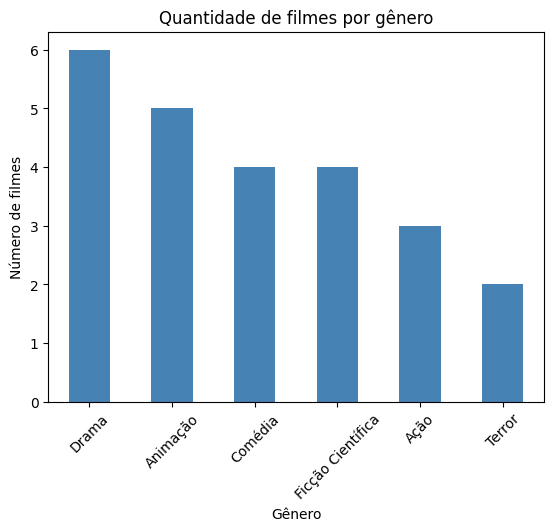

In [3]:
tabela_frequencia["Frequência absoluta"].plot(kind="bar", color="steelblue")
plt.title("Quantidade de filmes por gênero")
plt.ylabel("Número de filmes")
plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.show()

### 4.2 Gráfico de setores (pizza) — proporção de filmes por gênero

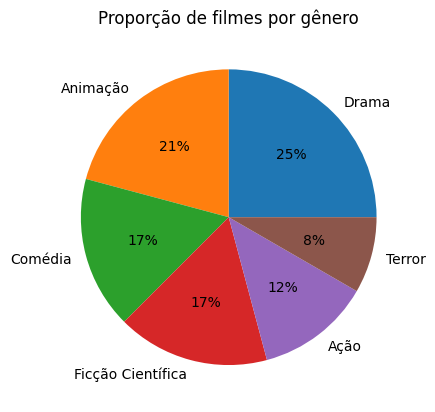

In [4]:
tabela_frequencia["Frequência absoluta"].plot(kind="pie", autopct="%1.0f%%", ylabel="")
plt.title("Proporção de filmes por gênero")
plt.show()

### 4.3 Gráfico de dispersão unidimensional — duração dos filmes

Cada ponto é um filme, espalhado ao longo do eixo de duração (em minutos).

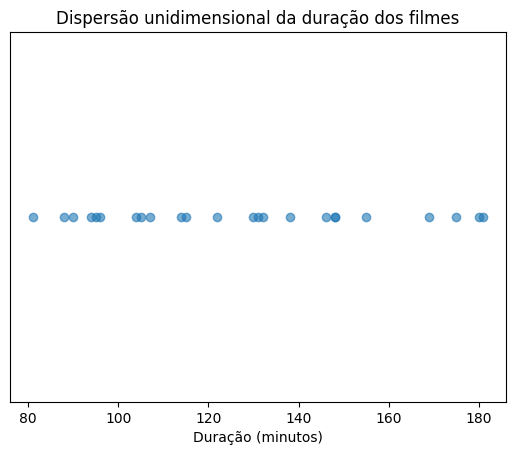

In [5]:
plt.scatter(df["duracao_minutos"], [1]*len(df), alpha=0.6)
plt.yticks([])
plt.xlabel("Duração (minutos)")
plt.title("Dispersão unidimensional da duração dos filmes")
plt.show()

### 4.4 Histograma — distribuição das notas do público

Diferente do gráfico de barras (que conta categorias), o histograma agrupa uma variável **contínua** em faixas (bins) — exatamente como vimos na aula.

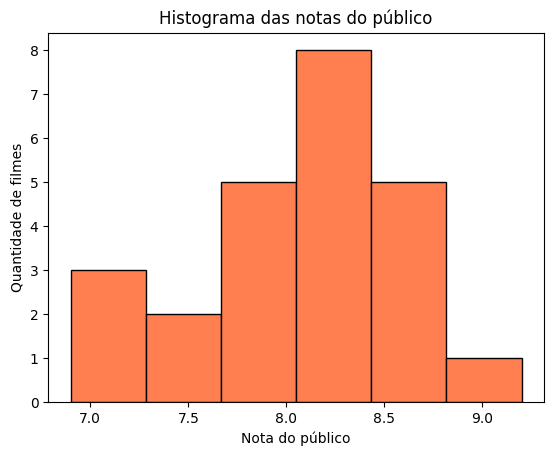

In [6]:
plt.hist(df["nota_publico"], bins=6, color="coral", edgecolor="black")
plt.xlabel("Nota do público")
plt.ylabel("Quantidade de filmes")
plt.title("Histograma das notas do público")
plt.show()

### 4.5 Ramo-e-folhas — duração dos filmes

O ramo-e-folhas é o único gráfico da aula que o Python não tem pronto de fábrica — mas dá pra montar em poucas linhas. O **ramo** é a dezena de minutos, e a **folha** é o dígito das unidades.

In [7]:
from collections import defaultdict

ramos = defaultdict(list)
for duracao in sorted(df["duracao_minutos"]):
    ramo, folha = divmod(duracao, 10)
    ramos[ramo].append(str(folha))

print("Ramo | Folhas")
print("-----+--------------------")
for ramo in sorted(ramos):
    print(f"{ramo:>4} | " + " ".join(ramos[ramo]))

Ramo | Folhas
-----+--------------------
   8 | 1 8
   9 | 0 4 5 6
  10 | 4 5 7
  11 | 4 5
  12 | 2
  13 | 0 1 2 8
  14 | 6 8 8
  15 | 5
  16 | 9
  17 | 5
  18 | 0 1


**Como ler**: a linha `9 | 0 4 5 6` significa que há filmes com 90, 94, 95 e 96 minutos de duração. É a mesma leitura que fizemos na aula, só que com dado real de filme em vez do exemplo do livro.

## 5. Medidas de posição — moda, mediana e média

Vamos calcular as três medidas de posição para a nota do público, exatamente como fizemos na aula.

In [8]:
media = df["nota_publico"].mean()
mediana = df["nota_publico"].median()
moda = df["nota_publico"].mode()[0]

print(f"Média:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda:    {moda:.2f}")

Média:   8.10
Mediana: 8.30
Moda:    8.40


**Pergunta para pensar** (a mesma que discutimos em aula sobre a diferença entre média e mediana): a média e a mediana das notas ficaram próximas ou distantes? Se a média fosse bem menor que a mediana, o que isso sugeriria sobre a distribuição das notas — que tem alguns filmes muito mal avaliados puxando a média para baixo, ou muito bem avaliados puxando para cima?

## 6. Curiosidade: e se eu usar OUTRA variável?

Repare que todo o código acima usa `df["nota_publico"]` ou `df["genero"]`. Se você quiser (só por curiosidade, não é obrigatório), pode copiar qualquer célula de gráfico acima, colar numa célula nova, e trocar o nome da coluna por `"duracao_minutos"` ou `"ano"` para ver a distribuição de outra variável. Não tem como quebrar nada — o pior que pode acontecer é dar um erro, e aí é só executar a célula original de novo.

## Para fechar

O que você acabou de ver com um banco de dados de filmes é literalmente o começo do que se chama **Ciência de Dados**: pegar uma tabela de informações reais e usar as ferramentas de estatística para entender padrões nela. As mesmas técnicas desse notebook — classificar variável, montar tabela de frequência, fazer gráfico, calcular média — são usadas para analisar desde filmes até decisões de saúde pública, resultado de eleição, ou recomendação de música no Spotify.

Se você curtiu mexer nisso, vale a pena ir salvando uma cópia deste notebook e testando outras ideias por conta própria ao longo do semestre — nenhuma delas vai valer nota, é só para quem tiver curiosidade.